In [2]:
!pip install matplotlib


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 524.9 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.5 MB 524.9 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.5 MB 524.9 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/9.5 MB 524.9 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/9.5 MB 399.7 kB/s e

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
!pip install seaborn


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
df = pd.read_csv("Walmart_Business_Analytics_Master_Dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
display(df.head())

Dataset loaded successfully!
Rows: 10000
Columns: 17


,Order_ID,Order_Date,Customer_ID,Customer_Segment,Product_Category,Product,Region,State,Sales,Quantity,Discount,Profit,Shipping_Cost,Ship_Mode,Payment_Mode,Sales_Channel,Customer_Rating
0,ORD100000,2024-11-07,CUST01899,Corporate,Furniture,Desk,East,New York,1058.65,5,0.1530,243.95,14.58,Second Class,Debit Card,Online,4.28
1,ORD100001,2023-07-23,CUST02199,Corporate,Furniture,Table,South,Florida,1482.13,4,0.0561,304.82,13.69,Standard,Credit Card,Store,3.53
2,ORD100002,2023-09-08,CUST00411,Consumer,Technology,Monitor,Central,Ohio,2323.86,8,0.1229,256.61,41.00,Standard,Credit Card,Online,3.09
3,ORD100003,2025-12-30,CUST02202,Corporate,Office Supplies,File Folder,Central,Illinois,773.85,8,0.1587,35.82,37.41,First Class,Debit Card,Online,4.09
4,ORD100004,2023-09-12,CUST00754,Consumer,Office Supplies,Notebook,West,California,666.59,10,0.0994,84.27,36.39,Standard,Credit Card,Online,4.18


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  str    
 1   Order_Date        10000 non-null  str    
 2   Customer_ID       10000 non-null  str    
 3   Customer_Segment  10000 non-null  str    
 4   Product_Category  10000 non-null  str    
 5   Product           10000 non-null  str    
 6   Region            10000 non-null  str    
 7   State             10000 non-null  str    
 8   Sales             10000 non-null  float64
 9   Quantity          10000 non-null  int64  
 10  Discount          10000 non-null  float64
 11  Profit            10000 non-null  float64
 12  Shipping_Cost     10000 non-null  float64
 13  Ship_Mode         10000 non-null  str    
 14  Payment_Mode      10000 non-null  str    
 15  Sales_Channel     10000 non-null  str    
 16  Customer_Rating   10000 non-null  float64
dtypes: fl

In [9]:
print("Missing values:")
display(df.isnull().sum())

Missing values:


Order_ID            0
Order_Date          0
Customer_ID         0
Customer_Segment    0
Product_Category    0
Product             0
Region              0
State               0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping_Cost       0
Ship_Mode           0
Payment_Mode        0
Sales_Channel       0
Customer_Rating     0
dtype: int64

In [10]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


In [11]:
display(df.dtypes)

Order_ID                str
Order_Date              str
Customer_ID             str
Customer_Segment        str
Product_Category        str
Product                 str
Region                  str
State                   str
Sales               float64
Quantity              int64
Discount            float64
Profit              float64
Shipping_Cost       float64
Ship_Mode               str
Payment_Mode            str
Sales_Channel           str
Customer_Rating     float64
dtype: object

In [12]:
columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping_Cost",
    "Customer_Rating"
]

display(df[columns].describe())

,Sales,Quantity,Discount,Profit,Shipping_Cost,Customer_Rating
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1072.049419,5.477300,0.106038,176.531654,24.504236,3.952813
std,1328.016091,2.876024,0.055677,262.310566,10.609915,0.461951
min,18.180000,1.000000,0.000800,-26.950000,9.200000,1.660000
25%,231.405000,3.000000,0.063500,17.347500,16.020000,3.640000
50%,474.600000,5.000000,0.097500,62.850000,22.705000,3.960000
75%,1456.180000,8.000000,0.139400,225.550000,31.172500,4.270000
max,7761.440000,10.000000,0.357200,1859.870000,64.860000,5.000000


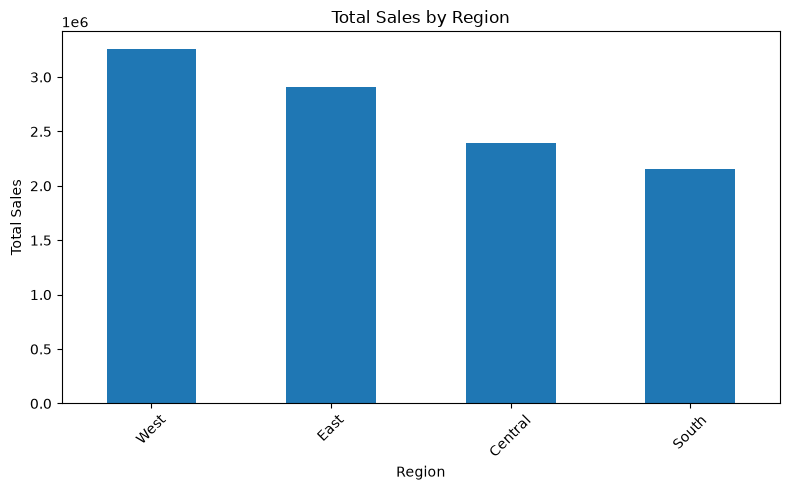

In [13]:
# 6.1 Total Sales by Region

sales_region = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_region.plot(kind="bar", figsize=(8, 5))
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

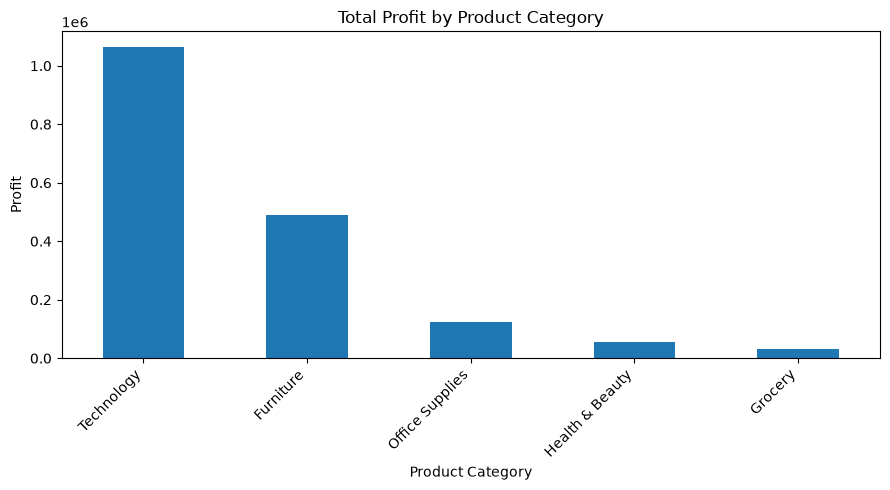

In [14]:
profit_category = (
    df.groupby("Product_Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_category.plot(kind="bar", figsize=(9, 5))
plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

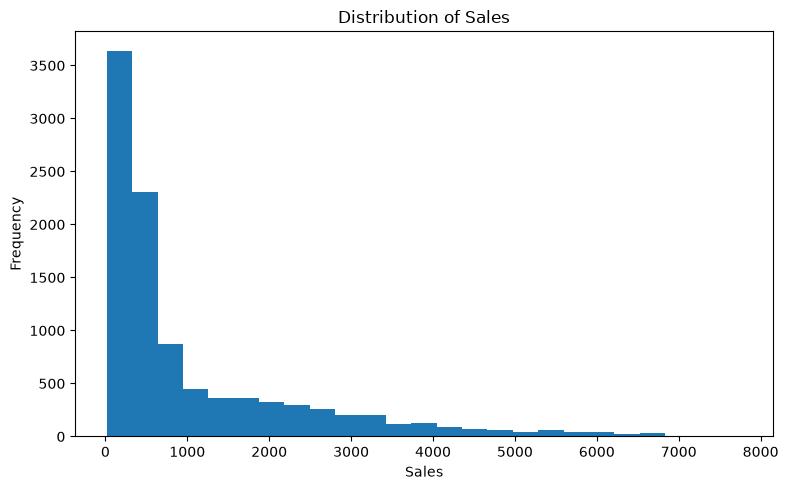

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df["Sales"].dropna(), bins=25)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

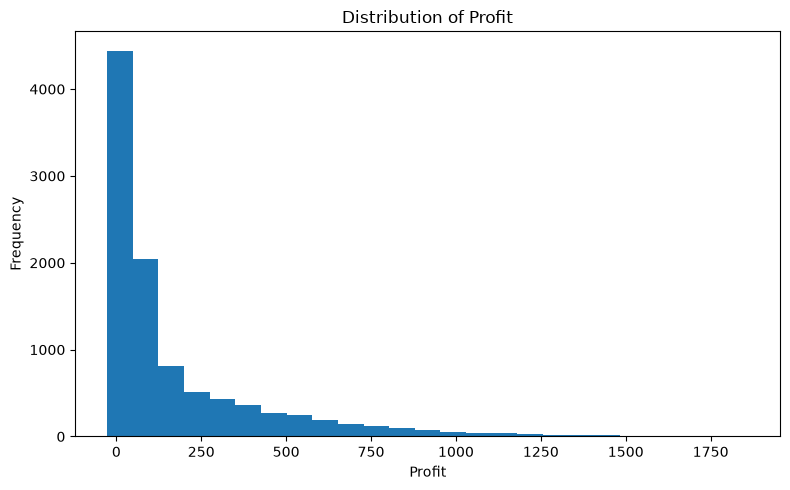

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["Profit"].dropna(), bins=25)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

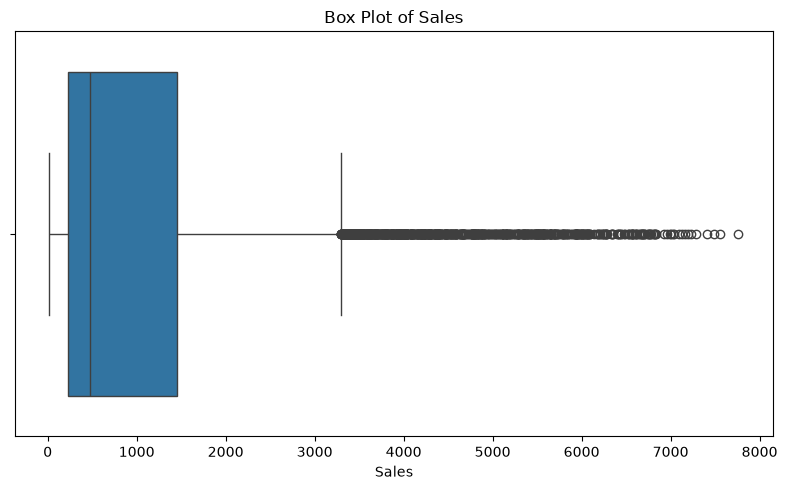

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Sales"])
plt.title("Box Plot of Sales")
plt.tight_layout()
plt.show()

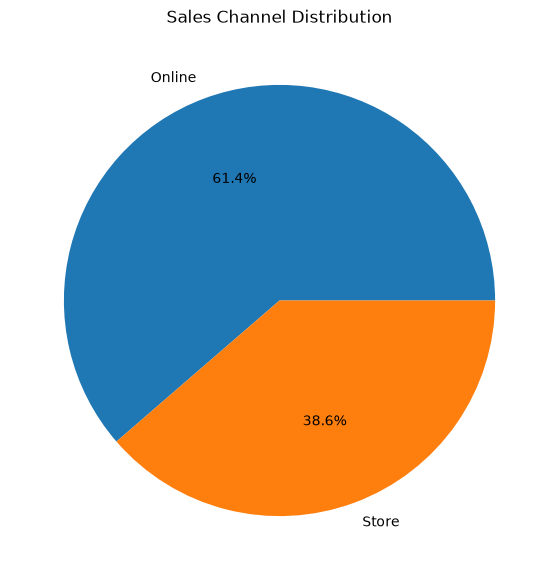

In [18]:
sales_channel = df["Sales_Channel"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    sales_channel,
    labels=sales_channel.index,
    autopct="%1.1f%%"
)
plt.title("Sales Channel Distribution")
plt.show()

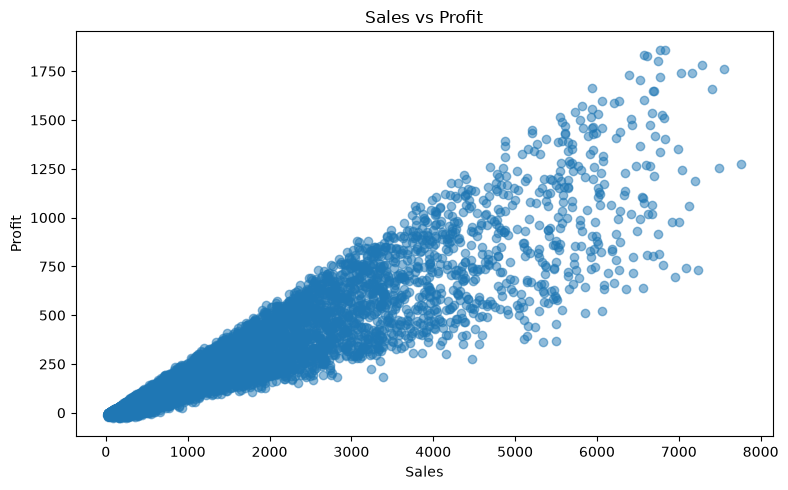

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Sales"],
    df["Profit"],
    alpha=0.5
)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

,Sales,Quantity,Discount,Profit,Shipping_Cost,Customer_Rating
Sales,1.000000,0.433040,-0.059262,0.936876,0.339779,0.058475
Quantity,0.433040,1.000000,0.001915,0.381222,0.771686,0.081938
Discount,-0.059262,0.001915,1.000000,-0.104639,-0.002111,-0.018654
Profit,0.936876,0.381222,-0.104639,1.000000,0.285491,0.054209
Shipping_Cost,0.339779,0.771686,-0.002111,0.285491,1.000000,0.031794
Customer_Rating,0.058475,0.081938,-0.018654,0.054209,0.031794,1.000000


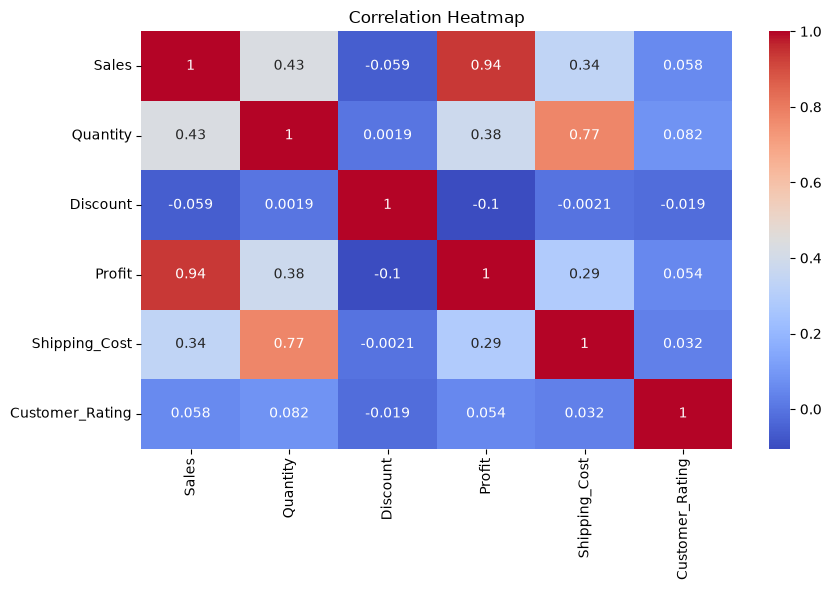

In [20]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping_Cost",
    "Customer_Rating"
]

correlation = df[numeric_columns].corr()

display(correlation)

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

regression_df = df[["Quantity", "Sales"]].dropna()

X = regression_df[["Quantity"]]
y = regression_df["Sales"]

model = LinearRegression()
model.fit(X, y)

prediction = model.predict(X)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R-squared:", r2_score(y, prediction))
print("MSE:", mean_squared_error(y, prediction))
print("RMSE:", np.sqrt(mean_squared_error(y, prediction)))


Coefficient: 199.95811293733595
Intercept: -23.181152991669933
R-squared: 0.18752375107950392
MSE: 1432761.545287601
RMSE: 1196.9801774831533


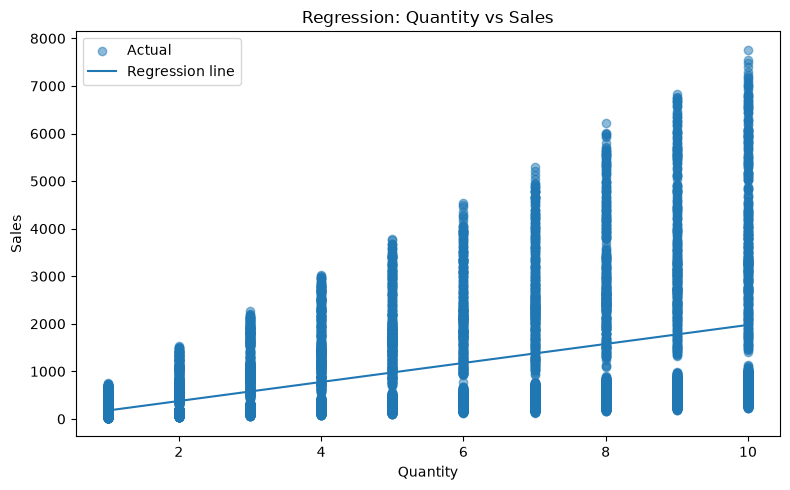

In [22]:
plot_df = regression_df.sort_values("Quantity")

plt.figure(figsize=(8, 5))
plt.scatter(
    regression_df["Quantity"],
    regression_df["Sales"],
    alpha=0.5,
    label="Actual"
)

plt.plot(
    plot_df["Quantity"],
    model.predict(plot_df[["Quantity"]]),
    label="Regression line"
)

plt.title("Regression: Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
total_records = len(df)

online_records = (
    df["Sales_Channel"]
    .astype(str)
    .str.lower()
    .eq("online")
).sum()

print(
    "Probability of Online sales:",
    online_records / total_records
    if total_records else 0
)

technology_records = (
    df["Product_Category"] == "Technology"
).sum()

print(
    "Probability of Technology category:",
    technology_records / total_records
    if total_records else 0
)

Probability of Online sales: 0.6135
Probability of Technology category: 0.2171


In [25]:
sample_sizes = [30, 50, 100]

sales = df["Sales"].dropna()

for size in sample_sizes:

    sample_means = []

    for _ in range(100):
        sample_means.append(
            sales.sample(size, replace=True).mean()
        )

    print("Sample size:", size)
    print(
        "Mean of sample means:",
        round(np.mean(sample_means), 2)
    )

    print(
        "Standard error:",
        round(np.std(sample_means, ddof=1), 2)
    )

Sample size: 30
Mean of sample means: 1072.49
Standard error: 223.57
Sample size: 50
Mean of sample means: 1055.49
Standard error: 170.51
Sample size: 100
Mean of sample means: 1073.29
Standard error: 129.92


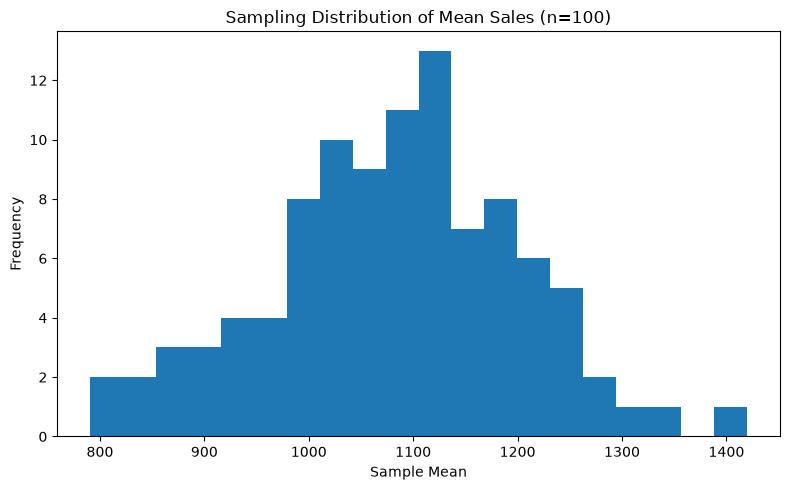

In [26]:
sales = df["Sales"].dropna()

sample_means = [
    sales.sample(100, replace=True).mean()
    for _ in range(100)
]

plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=20)
plt.title("Sampling Distribution of Mean Sales (n=100)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [27]:
from scipy import stats

sales = df["Sales"].dropna()

mean = sales.mean()
n = len(sales)

standard_error = stats.sem(sales)

lower, upper = stats.t.interval(
    0.95,
    df=n-1,
    loc=mean,
    scale=standard_error
)

print("Mean Sales:", round(mean, 2))

print(
    "95% Confidence Interval:",
    (round(lower, 2), round(upper, 2))
)

Mean Sales: 1072.05
95% Confidence Interval: (np.float64(1046.02), np.float64(1098.08))


Bootstrap mean: 1071.74
Bootstrap 95% confidence interval: (np.float64(1046.94), np.float64(1096.19))


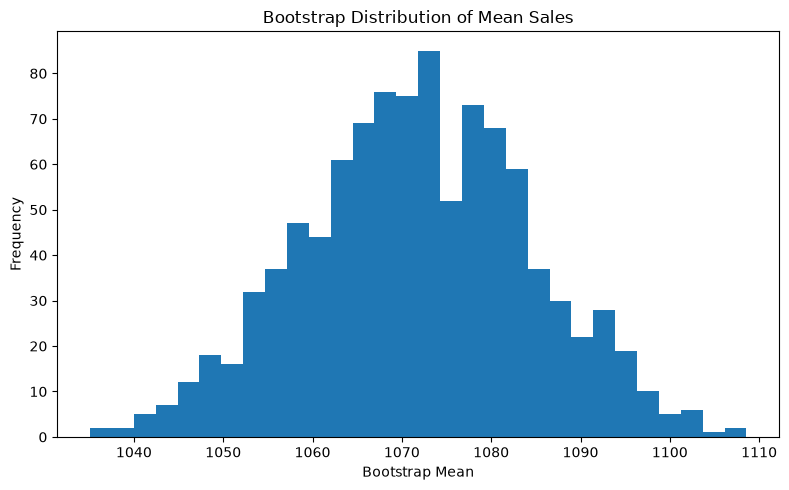

In [28]:
sales = df["Sales"].dropna().to_numpy()

bootstrap_means = []

for _ in range(1000):

    bootstrap_sample = np.random.choice(
        sales,
        size=len(sales),
        replace=True
    )

    bootstrap_means.append(
        bootstrap_sample.mean()
    )

lower, upper = np.percentile(
    bootstrap_means,
    [2.5, 97.5]
)

print(
    "Bootstrap mean:",
    round(np.mean(bootstrap_means), 2)
)

print(
    "Bootstrap 95% confidence interval:",
    (round(lower, 2), round(upper, 2))
)

plt.figure(figsize=(8, 5))
plt.hist(bootstrap_means, bins=30)
plt.title("Bootstrap Distribution of Mean Sales")
plt.xlabel("Bootstrap Mean")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [29]:
from scipy.stats import ttest_1samp

sales = df["Sales"].dropna()

benchmark = 500

result = ttest_1samp(
    sales,
    popmean=benchmark
)

print("H0: Mean Sales = 500")
print("H1: Mean Sales is different from 500")
print("t-statistic:", result.statistic)
print("p-value:", result.pvalue)

print(
    "Decision:",
    "Reject H0"
    if result.pvalue < 0.05
    else "Fail to reject H0"
)


H0: Mean Sales = 500
H1: Mean Sales is different from 500
t-statistic: 43.075488545067884
p-value: 0.0
Decision: Reject H0


In [31]:
ab = pd.read_csv(
    "Walmart_AB_Testing_Dataset.csv"
)

display(ab.head())

display(
    ab.groupby("Variant")["Converted"]
    .agg(["sum", "count", "mean"])
)

,Customer_ID,Variant,Converted
0,AB10000,B,0
1,AB10001,B,0
2,AB10002,B,1
3,AB10003,A,0
4,AB10004,B,0


,sum,count,mean
Variant,,,
A,108,1003,0.107677
B,140,997,0.140421


In [33]:
!pip install statsmodels


   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 447.8 kB/s eta 0:00:25
   - -------------------------------------- 0.5/11.3 MB 447.8 kB/s eta 0:00:25
   - -------------------------------------- 0.5/11.3 MB 447.8 kB/s eta 0:00:25
   -- ------------------------------------- 0.8/11.3 MB 417.6 kB/s eta 0:00:26
   -- ------------------------------------- 0.8/11.3 M

In [34]:
from statsmodels.stats.proportion import proportions_ztest

summary = (
    ab.groupby("Variant")["Converted"]
    .agg(["sum", "count"])
)

z_stat, p_value = proportions_ztest(
    summary["sum"].to_numpy(),
    summary["count"].to_numpy()
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

print(
    "Decision:",
    "Significant difference"
    if p_value < 0.05
    else "No significant difference detected"
)

Z-statistic: -2.221548466454159
P-value: 0.02631383584986329
Decision: Significant difference


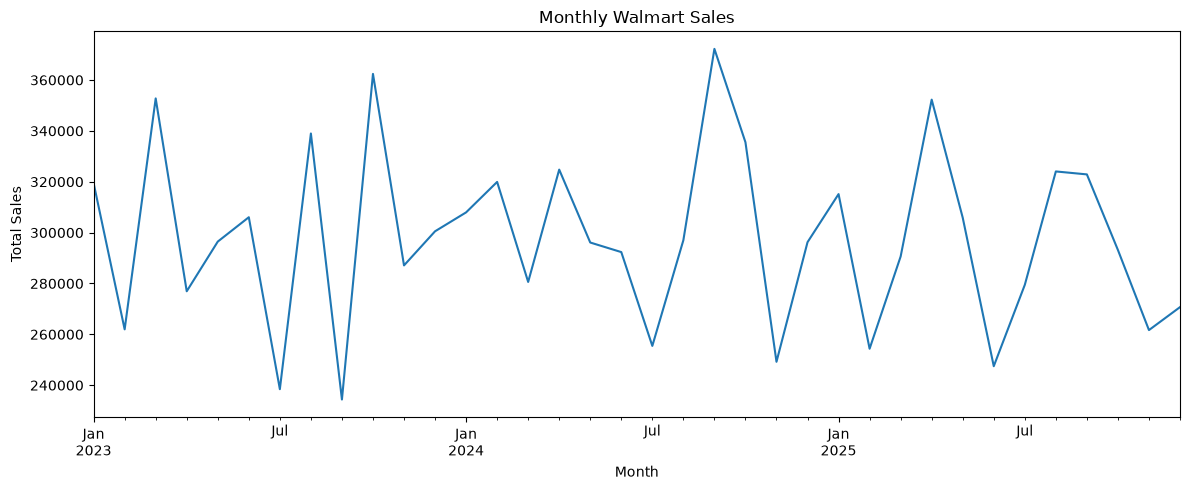

In [35]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

dated_df = df.dropna(
    subset=["Order_Date"]
).copy()

monthly_sales = (
    dated_df
    .groupby(
        dated_df["Order_Date"].dt.to_period("M")
    )["Sales"]
    .sum()
)

monthly_sales.index = (
    monthly_sales.index.to_timestamp()
)

monthly_sales.plot(figsize=(12, 5))

plt.title("Monthly Walmart Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

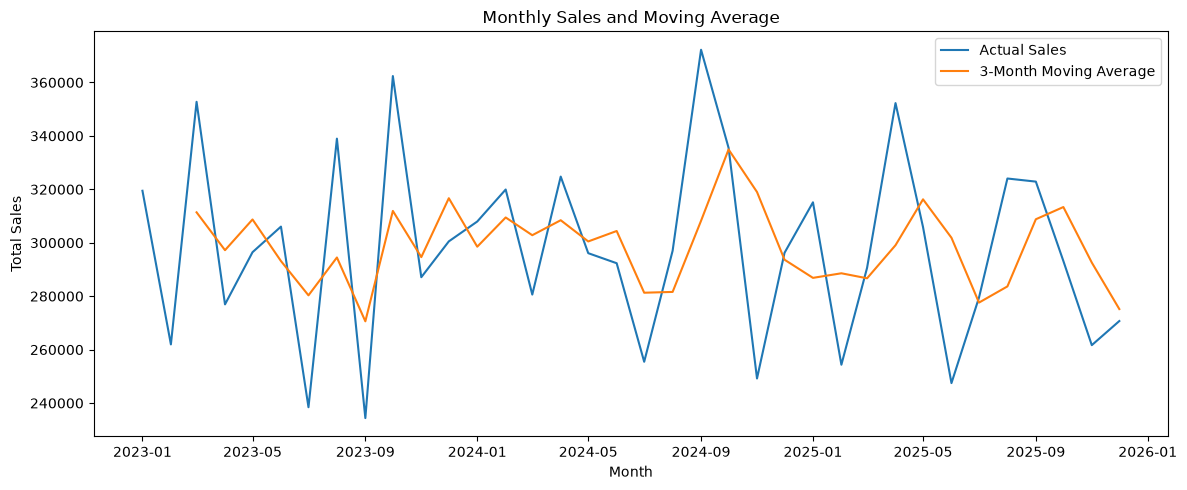

In [36]:
moving_average = monthly_sales.rolling(
    window=3
).mean()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Actual Sales"
)

plt.plot(
    moving_average.index,
    moving_average.values,
    label="3-Month Moving Average"
)

plt.title("Monthly Sales and Moving Average")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
simulation = pd.read_csv(
    "Walmart_Simulation_Dataset.csv"
)

print(
    "Available columns:",
    simulation.columns.tolist()
)

display(simulation.head())

numeric_cols = (
    simulation
    .select_dtypes(include="number")
    .columns
    .tolist()
)

display(
    simulation
    .groupby("Scenario")[numeric_cols]
    .mean()
)


Available columns: ['Scenario', 'Demand_Units', 'Average_Price', 'Sales', 'Profit']


,Scenario,Demand_Units,Average_Price,Sales,Profit
0,Normal,105,92.03,9644.47,1831.78
1,Normal,117,104.90,12264.04,1591.01
2,High,140,86.39,12087.99,2988.87
3,Normal,108,102.86,11126.15,1583.21
4,Normal,79,50.49,4001.63,863.20


,Demand_Units,Average_Price,Sales,Profit
Scenario,,,,
High,149.785915,78.024507,11712.958451,2352.071775
Low,70.356955,77.629528,5471.856693,1090.192782
Normal,109.073298,77.118887,8406.137291,1663.107762


In [39]:
from scipy.stats import f_oneway

groups = []
group_names = []

for name, group in df.groupby("Sales_Channel"):

    values = group["Profit"].dropna()

    if len(values) > 1:

        groups.append(values)
        group_names.append(name)

print("Groups tested:", group_names)

if len(groups) >= 2:

    f_stat, p_value = f_oneway(*groups)

    print("F-statistic:", f_stat)
    print("P-value:", p_value)

    print(
        "Decision:",
        "Significant difference"
        if p_value < 0.05
        else "No significant difference detected"
    )

else:
    print("At least two groups are required.")

Groups tested: ['Online', 'Store']
F-statistic: 1.6051487786677547
P-value: 0.20520458880856676
Decision: No significant difference detected


Available columns: ['Sales_Method', 'Sales_Volume_Group', 'Replication', 'Operating_Profit']


,Sales_Method,Sales_Volume_Group,Replication,Operating_Profit
0,Online,Low,1,149.881266
1,Online,Low,2,154.980759
2,Online,Low,3,86.591550
3,Online,Low,4,114.502199
4,Online,Low,5,101.119999


Sales_Volume_Group,High,Low,Medium
Sales_Method,,,
Online,370.717331,112.890591,222.751165
Store,326.926149,101.168395,201.134823


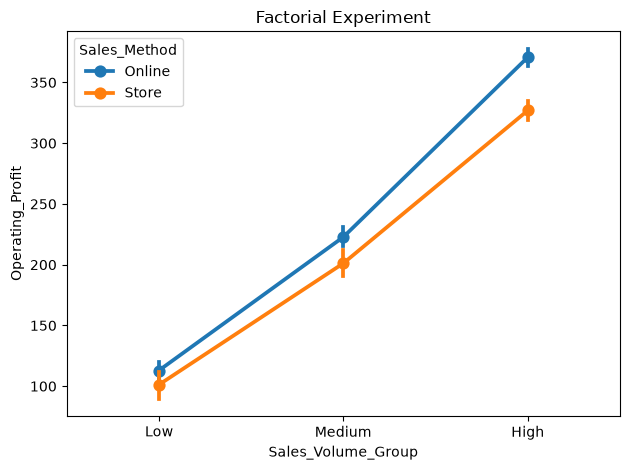

In [41]:
factorial = pd.read_csv(
    "Walmart_Factorial_Experiment_Dataset.csv"
)

print(
    "Available columns:",
    factorial.columns.tolist()
)

display(factorial.head())

if {
    "Sales_Method",
    "Sales_Volume_Group",
    "Operating_Profit"
}.issubset(factorial.columns):

    display(
        factorial
        .groupby(
            ["Sales_Method", "Sales_Volume_Group"]
        )["Operating_Profit"]
        .mean()
        .unstack()
    )

    sns.pointplot(
        data=factorial,
        x="Sales_Volume_Group",
        y="Operating_Profit",
        hue="Sales_Method"
    )

    plt.title("Factorial Experiment")
    plt.tight_layout()
    plt.show()

else:
    print(
        "Expected columns not found; check the column list above."
    )

In [43]:

decision = pd.read_csv(
    "Walmart_Decision_Making_Dataset.csv"
)

print(
    "Available columns:",
    decision.columns.tolist()
)

display(decision.head())

decision["Expected_Value_Component"] = (
    decision["Probability"] *
    decision["Payoff_INR"]
)

values = (
    decision
    .groupby("Alternative")["Expected_Value_Component"]
    .sum()
    .sort_values(ascending=False)
)

display(values)

print(
    "Best alternative:",
    values.idxmax()
)

print(
    "Expected value:",
    values.max()
)

Available columns: ['Alternative', 'Scenario', 'Probability', 'Payoff_INR']


,Alternative,Scenario,Probability,Payoff_INR
0,Increase Online Advertising,Low,0.25,180000
1,Increase Online Advertising,Normal,0.50,320000
2,Increase Online Advertising,High,0.25,500000
3,Open New Store,Low,0.25,80000
4,Open New Store,Normal,0.50,280000


Alternative
Increase Online Advertising    330000.0
Open New Store                 310000.0
Increase Discounts             285000.0
Name: Expected_Value_Component, dtype: float64

Best alternative: Increase Online Advertising
Expected value: 330000.0


In [44]:
optimization = pd.read_csv(
    "Walmart_Optimization_Input_Dataset.csv"
)

display(optimization)

print(
    "Products:",
    optimization["Product"].tolist()
)

# Linear programming model:
# Maximize total profit subject to budget, labor and product limits.

try:

    from pulp import (
        LpMaximize,
        LpProblem,
        LpVariable,
        lpSum,
        LpStatus,
        value
    )

    problem = LpProblem(
        "Walmart_Profit_Optimization",
        LpMaximize
    )

    product_vars = {}

    for _, row in optimization.iterrows():

        product_vars[row["Product"]] = LpVariable(
            row["Product"].replace(" ", "_"),
            lowBound=0,
            upBound=row["Max_Units"],
            cat="Integer"
        )

    # Resource limits for academic demonstration
    budget_limit = 5000000
    labor_limit = 1200

    problem += lpSum(
        product_vars[row["Product"]] *
        row["Profit_Per_Unit"]
        for _, row in optimization.iterrows()
    )

    problem += lpSum(
        product_vars[row["Product"]] *
        row["Budget_Per_Unit"]
        for _, row in optimization.iterrows()
    ) <= budget_limit

    problem += lpSum(
        product_vars[row["Product"]] *
        row["Labor_Hours_Per_Unit"]
        for _, row in optimization.iterrows()
    ) <= labor_limit

    problem.solve()

    print("Optimization Status:", LpStatus[problem.status])

    print("Optimal Product Allocation:")

    for product, variable in product_vars.items():
        print(product, ":", variable.value())

    print(
        "Maximum Expected Profit:",
        value(problem.objective)
    )

except ImportError:

    print(
        "PuLP is not installed. Run: pip install pulp"
    )

,Product,Profit_Per_Unit,Sales_Per_Unit,Labor_Hours_Per_Unit,Budget_Per_Unit,Max_Units
0,Laptop,8500,62000,2.5,48000,150
1,Smartphone,5200,42000,1.8,33000,220
2,Office Chair,2400,12000,1.2,8200,300
3,Printer Paper,450,1800,0.4,1200,700
4,Coffee,320,900,0.3,600,900
5,Skin Care,700,2500,0.5,1600,500


Products: ['Laptop', 'Smartphone', 'Office Chair', 'Printer Paper', 'Coffee', 'Skin Care']
PuLP is not installed. Run: pip install pulp


In [45]:
print("WALMART BUSINESS ANALYTICS SUMMARY")
print("-----------------------------------")

print(
    "Total Sales:",
    round(df["Sales"].sum(), 2)
)

print(
    "Total Profit:",
    round(df["Profit"].sum(), 2)
)

print(
    "Total Units Sold:",
    round(df["Quantity"].sum(), 2)
)

print(
    "Average Discount:",
    round(df["Discount"].mean() * 100, 2),
    "%"
)

print(
    "Average Customer Rating:",
    round(df["Customer_Rating"].mean(), 2)
)

print(
    "Unique Customers:",
    df["Customer_ID"].nunique()
)

WALMART BUSINESS ANALYTICS SUMMARY
-----------------------------------
Total Sales: 10720494.19
Total Profit: 1765316.54
Total Units Sold: 54773
Average Discount: 10.6 %
Average Customer Rating: 3.95
Unique Customers: 2454


In [46]:

print("\nBUSINESS RECOMMENDATIONS")
print("------------------------")
print("1. Focus on regions with higher sales and profit.")
print("2. Improve the performance of low-profit product categories.")
print("3. Monitor discounts because excessive discounts can reduce profit.")
print("4. Use sales forecasts for inventory and demand planning.")
print("5. Compare online and store performance before allocating resources.")
print("6. Use A/B testing before introducing major promotional campaigns.")
print("7. Use simulation to prepare for low, normal and high demand.")
print("8. Use optimization to allocate limited budget and labor resources.")



BUSINESS RECOMMENDATIONS
------------------------
1. Focus on regions with higher sales and profit.
2. Improve the performance of low-profit product categories.
3. Monitor discounts because excessive discounts can reduce profit.
4. Use sales forecasts for inventory and demand planning.
5. Compare online and store performance before allocating resources.
6. Use A/B testing before introducing major promotional campaigns.
7. Use simulation to prepare for low, normal and high demand.
8. Use optimization to allocate limited budget and labor resources.
